# 02 — Análisis Estratégico: 5 Ejes de Negocio
Análisis profundo del dataset de ventas de vending machines organizado en 5 ejes estratégicos:
rendimiento por máquina, patrones temporales, eficiencia del planograma, rentabilidad por producto
y segmentación de puntos de venta (base para K-Means).

In [6]:
import sys
sys.path.insert(0, "..")

import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams['figure.figsize'] = (13, 5)
sns.set_theme(style='whitegrid')

# Carga el snapshot más reciente
snapshot_path = sorted(glob.glob('../data/snapshots/buckkmrgh_*.csv'))[-1]
print(f'Cargando: {snapshot_path}')

df = pd.read_csv(snapshot_path)
df['Sale Register Date'] = pd.to_datetime(df['Sale Register Date'], utc=True)
df['Date Created']       = pd.to_datetime(df['Date Created'],       utc=True)

print(f'Filas: {len(df):,} | Columnas: {df.shape[1]}')

Cargando: ../data/snapshots\buckkmrgh_20260330_091639.csv
Filas: 271,789 | Columnas: 24


---
## Eje 1 — Rendimiento por máquina y ubicación
Cruza `vm_control` con `POS Location`, `Customer` y `Operation Center` para identificar
qué máquinas generan mayor `Total Sale` y cuáles tienen bajo rendimiento.
Alimenta directamente el objetivo de segmentación.

In [7]:
# Rendimiento total por máquina
vm_perf = (
    df.groupby('vm_control')
    .agg(
        total_sale    = ('Total Sale',      'sum'),
        n_transac     = ('SALES_DETAIL ID', 'count'),
        avg_ticket    = ('Total Sale',      'mean'),
        pos_location  = ('POS Location',    'first'),
        customer      = ('Customer',        'first'),
        op_center     = ('Operation Center','first'),
    )
    .sort_values('total_sale', ascending=False)
    .reset_index()
)

print(f'Total máquinas únicas: {len(vm_perf):,}')
print('\n--- Top 10 máquinas por Total Sale ---')
display(vm_perf.head(10)[['vm_control','pos_location','customer','op_center','total_sale','n_transac','avg_ticket']])

print('\n--- Bottom 10 máquinas (menor venta) ---')
display(vm_perf.tail(10)[['vm_control','pos_location','customer','op_center','total_sale','n_transac','avg_ticket']])

Total máquinas únicas: 405

--- Top 10 máquinas por Total Sale ---


,vm_control,pos_location,customer,op_center,total_sale,n_transac,avg_ticket
0,25475,Dismas Charities - Back,Dismas Charities,El Paso,45011.75,7861,5.725957
1,36014,Dismas Charities - Back,Dismas Charities,El Paso,17771.50,1918,9.265641
2,36812,Administration - 25 McGregor Range Road,Otero County Processing Center,El Paso,11535.45,1621,7.116255
3,28046,UTEP - Library - Basement,University of Texas at El Paso,El Paso,10801.00,2851,3.788495
4,24378,McGregor Range Bldg 9451 - 9451 Ledford,AAFES Fort Bliss,El Paso,10423.25,2284,4.563595
5,25783,Administration - 25 McGregor Range Road,Otero County Processing Center,El Paso,10168.50,2720,3.738419
6,37610,Werner - Back Breakroom,Werner Inc,El Paso,9992.50,1030,9.701456
7,35710,Dismas Charities TEST -,Dismas Charities,El Paso,9897.75,1198,8.261895
8,24370,McGregor Range Bldg 9449 - 9449 Ledford,AAFES Fort Bliss,El Paso,9781.45,2102,4.653402
9,24359,University of Texas at El Paso - 500 West Univ...,University of Texas at El Paso,El Paso,9696.25,2702,3.588546



--- Bottom 10 máquinas (menor venta) ---


,vm_control,pos_location,customer,op_center,total_sale,n_transac,avg_ticket
395,20889,Bldg 777 Breakroom - 777 Chaffee Road,AAFES Fort Bliss,El Paso,40.75,17,2.397059
396,24193,Bldg 503 Front Canopy - 6700 Delta Drive,El Paso State Center,El Paso,38.75,18,2.152778
397,24161,Bldg 611 Breakroom -,AAFES Fort Bliss,El Paso,38.25,16,2.390625
398,24394,20187 Minue Drive - 20187 Minue Drive,AAFES Fort Bliss,El Paso,36.25,9,4.027778
399,26529,Bldg 20500 1st Floor -,AAFES Fort Bliss,El Paso,33.75,11,3.068182
400,25739,516 Pleasonton Road - 516 Pleasonton Road,AAFES Fort Bliss,El Paso,33.00,14,2.357143
401,14992,UTEP - Library - Basement,University of Texas at El Paso,El Paso,30.25,17,1.779412
402,24309,Rod Mill - 6999 N Loop Dr,Phelps Dodge/ Freeport McMoran,El Paso,22.75,10,2.275000
403,35535,Bldg 503 Front Canopy - 6700 Delta Drive,El Paso State Center,El Paso,19.25,2,9.625000
404,25678,Camp - 8500 Doniphan Road,Federal Corrections Inst. La Tuna,El Paso,2.50,1,2.500000


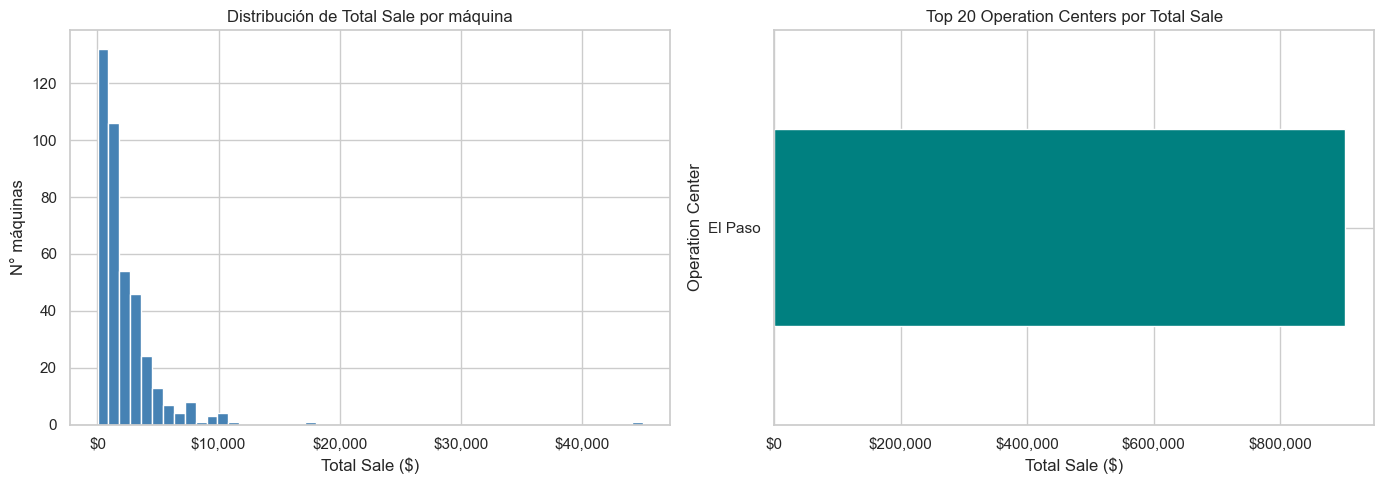

In [8]:
# Distribución de ventas totales por máquina
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(vm_perf['total_sale'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Total Sale por máquina')
axes[0].set_xlabel('Total Sale ($)')
axes[0].set_ylabel('N° máquinas')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Top 20 por Operation Center
oc_perf = df.groupby('Operation Center')['Total Sale'].sum().sort_values(ascending=False).head(20)
oc_perf.plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Top 20 Operation Centers por Total Sale')
axes[1].set_xlabel('Total Sale ($)')
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

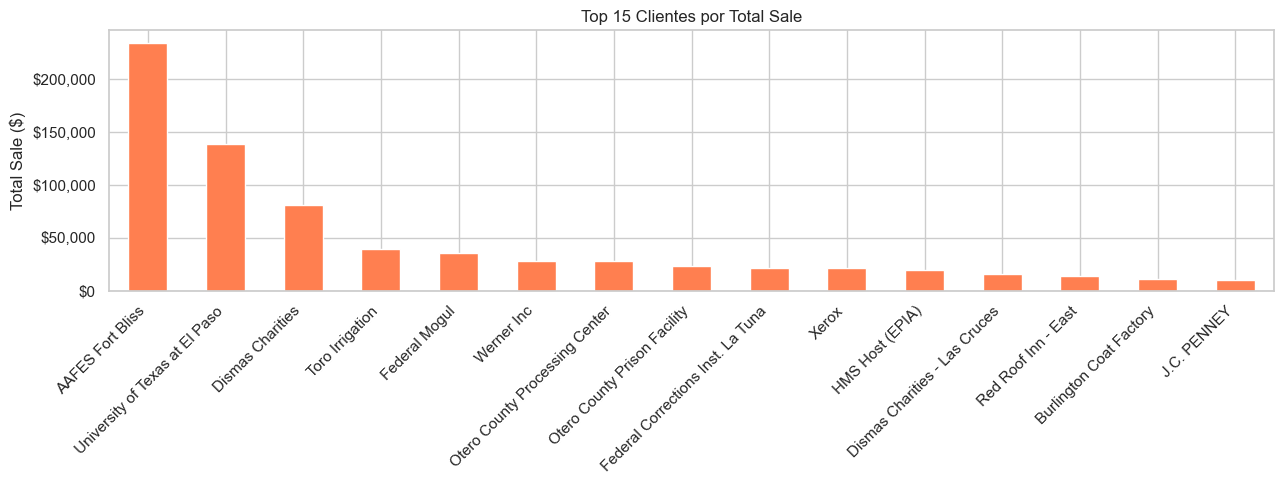

In [9]:
# Top 15 clientes por venta total
cust_perf = df.groupby('Customer')['Total Sale'].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(13, 5))
cust_perf.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Top 15 Clientes por Total Sale')
ax.set_ylabel('Total Sale ($)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## Eje 2 — Patrones temporales de consumo
Descompone las ventas por día de semana, semana del mes y mes del año usando `Sale Register Date`.
Permite detectar estacionalidad y diferencias entre tipos de ubicación.

In [10]:
# Extraer componentes temporales
df['dow']         = df['Sale Register Date'].dt.dayofweek          # 0=Lun … 6=Dom
df['dow_name']    = df['Sale Register Date'].dt.day_name()
df['week_of_month']= df['Sale Register Date'].dt.day.apply(lambda d: (d - 1) // 7 + 1)
df['month']       = df['Sale Register Date'].dt.month
df['month_name']  = df['Sale Register Date'].dt.month_name()
df['year']        = df['Sale Register Date'].dt.year

DOW_ORDER   = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
MONTH_ORDER = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

print('Columnas temporales creadas: dow, dow_name, week_of_month, month, month_name, year')

Columnas temporales creadas: dow, dow_name, week_of_month, month, month_name, year


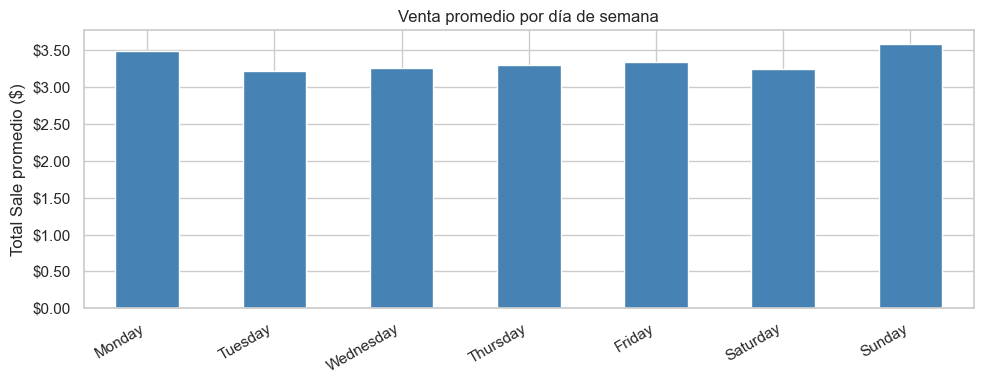

In [11]:
# Venta promedio por día de semana
dow_sale = (
    df.groupby('dow_name')['Total Sale']
    .mean()
    .reindex(DOW_ORDER)
)

fig, ax = plt.subplots(figsize=(10, 4))
dow_sale.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Venta promedio por día de semana')
ax.set_ylabel('Total Sale promedio ($)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.2f}'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

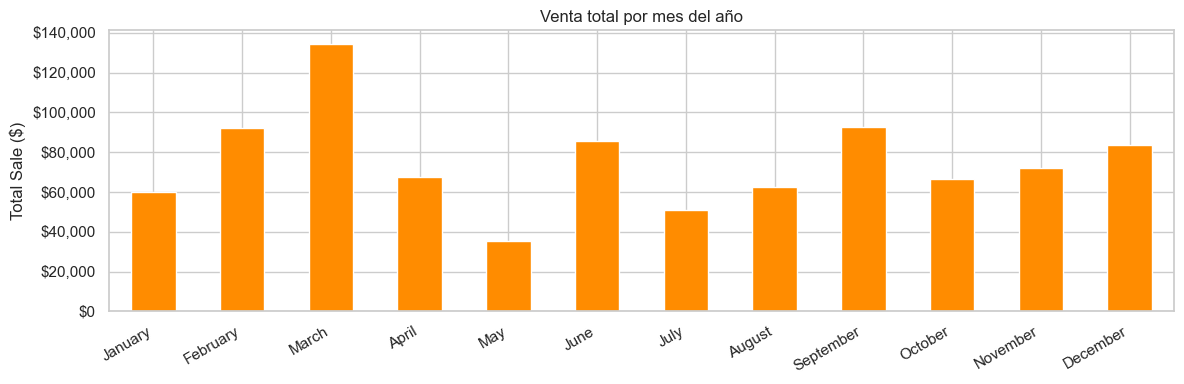

In [12]:
# Venta total por mes del año (agregado sobre todos los años)
month_sale = (
    df.groupby('month_name')['Total Sale']
    .sum()
    .reindex(MONTH_ORDER)
)

fig, ax = plt.subplots(figsize=(12, 4))
month_sale.plot(kind='bar', ax=ax, color='darkorange', edgecolor='white')
ax.set_title('Venta total por mes del año')
ax.set_ylabel('Total Sale ($)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

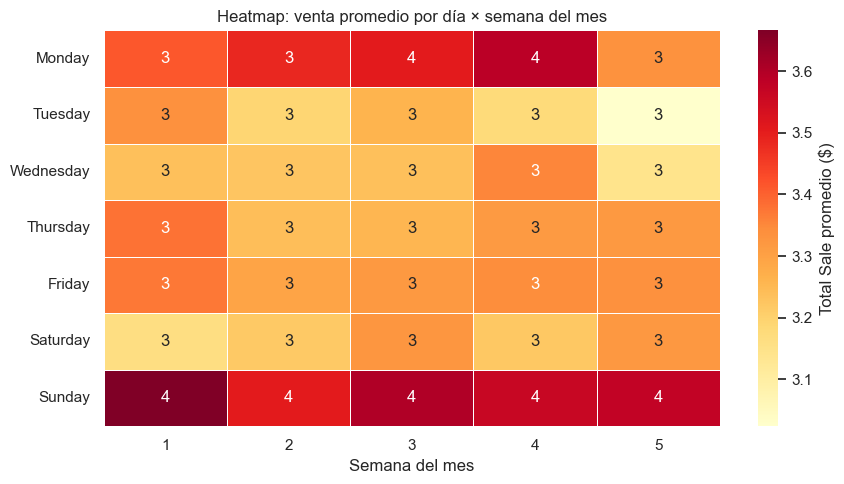

In [13]:
# Heatmap: día de semana × semana del mes
hm_data = (
    df.groupby(['dow_name', 'week_of_month'])['Total Sale']
    .mean()
    .unstack('week_of_month')
    .reindex(DOW_ORDER)
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(hm_data, ax=ax, cmap='YlOrRd', fmt='.0f', annot=True,
            linewidths=0.5, cbar_kws={'label': 'Total Sale promedio ($)'})
ax.set_title('Heatmap: venta promedio por día × semana del mes')
ax.set_xlabel('Semana del mes')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

---
## Eje 3 — Eficiencia del planograma
Compara `Par` (capacidad teórica) vs `Quantity Sale` por `Selection` y `Product Name`
para detectar posiciones con riesgo de stock-out y posiciones con rotación lenta.

In [14]:
# Filtrar filas con Par > 0 para evitar divisiones por cero
plano = df[df['Par'].notna() & (df['Par'] > 0)].copy()

plano_prod = (
    plano.groupby('Product Name')
    .agg(
        avg_par          = ('Par',           'mean'),
        total_qty_sale   = ('Quantity Sale',  'sum'),
        n_registros      = ('SALES_DETAIL ID','count'),
    )
    .assign(fill_rate = lambda x: x['total_qty_sale'] / (x['avg_par'] * x['n_registros']))
    .sort_values('fill_rate', ascending=False)
    .reset_index()
)

print('--- Top 10 productos con mayor fill-rate (riesgo stock-out) ---')
display(plano_prod.head(10))

print('\n--- Bottom 10 productos con menor fill-rate (rotación lenta) ---')
display(plano_prod.dropna(subset=['fill_rate']).tail(10))

--- Top 10 productos con mayor fill-rate (riesgo stock-out) ---


,Product Name,avg_par,total_qty_sale,n_registros,fill_rate
0,Folgers Special Roast Ground 42/8oz,10.000000,40.0,2,2.000000
1,Alterra House Blend Decaf 5/20/.25oz,10.000000,16.0,1,1.600000
2,Brew Rite Base Large Filters 500ct,10.000000,35.0,3,1.166667
3,White Castle Cheeseburger,2.000000,50.0,36,0.694444
4,OM Lunchable Turkey & Ched,3.000000,36.0,23,0.521739
5,Welchs Fruit Snk Mixed Fruit,10.000000,58.0,13,0.446154
6,Equal Packets Blue 2000ct,10.000000,4.0,1,0.400000
7,Deli Express Oven Rst Tky Chs,3.965517,45.0,29,0.391304
8,Raybern Pastrami Cheese,4.358491,81.0,53,0.350649
9,Lifesavers Peppermint Mints,3.000000,2.0,2,0.333333



--- Bottom 10 productos con menor fill-rate (rotación lenta) ---


,Product Name,avg_par,total_qty_sale,n_registros,fill_rate
128,Coke Zero 12oz,38.635926,2539.0,1453,0.045228
129,Coke 20oz,49.827510,18277.0,8128,0.045129
130,Dr Pepper Diet 12oz,36.923077,126.0,78,0.043750
131,Monster Zero Ultra Energy 16oz,40.565632,736.0,419,0.043302
132,Fanta Orange 12oz,46.362014,2988.0,1569,0.041077
133,Coke Diet 12oz,44.540973,2490.0,1501,0.037244
134,Sprite 12oz,60.234417,4106.0,1877,0.036317
135,Coke Cherry 12oz,55.149419,3458.0,1807,0.034700
136,Dr Pepper 12oz,68.784429,5252.0,2389,0.031961
137,Coke 12oz,94.575401,8862.0,3488,0.026864


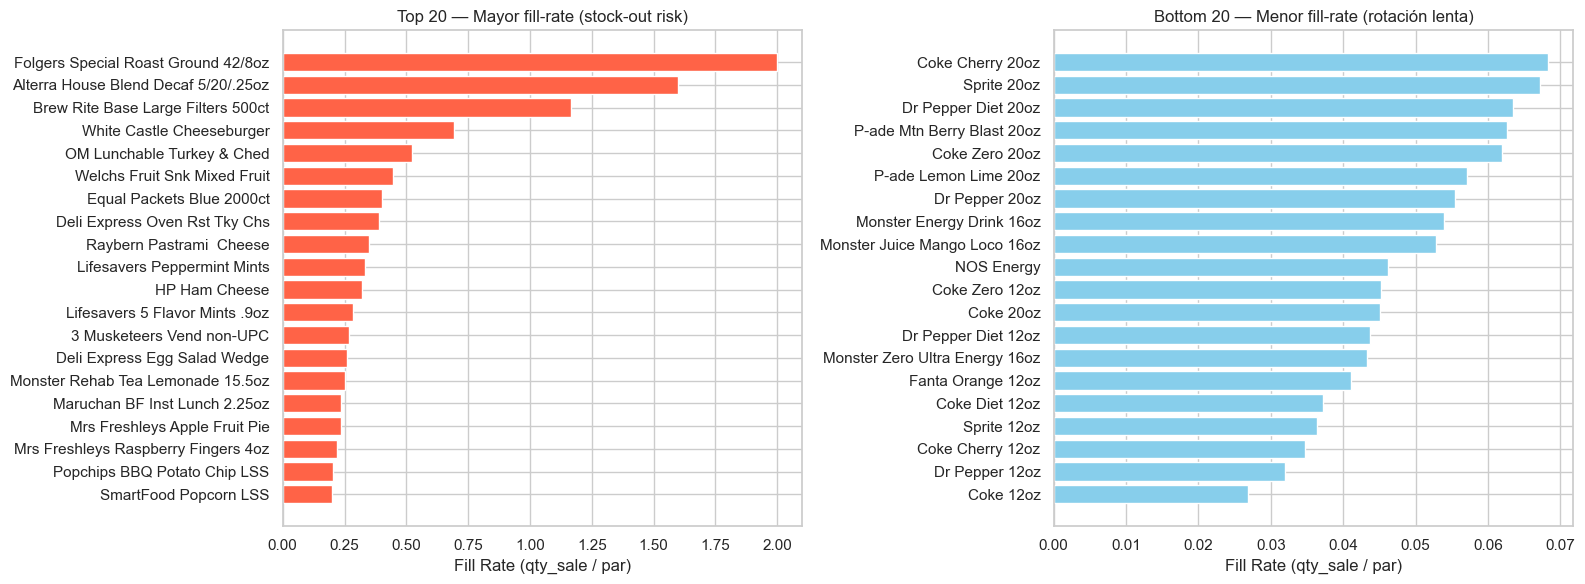

In [15]:
# Top 20 y Bottom 20 por fill-rate
top20  = plano_prod.dropna(subset=['fill_rate']).head(20)
bot20  = plano_prod.dropna(subset=['fill_rate']).tail(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top20['Product Name'], top20['fill_rate'], color='tomato')
axes[0].set_title('Top 20 — Mayor fill-rate (stock-out risk)')
axes[0].set_xlabel('Fill Rate (qty_sale / par)')
axes[0].invert_yaxis()

axes[1].barh(bot20['Product Name'], bot20['fill_rate'], color='skyblue')
axes[1].set_title('Bottom 20 — Menor fill-rate (rotación lenta)')
axes[1].set_xlabel('Fill Rate (qty_sale / par)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

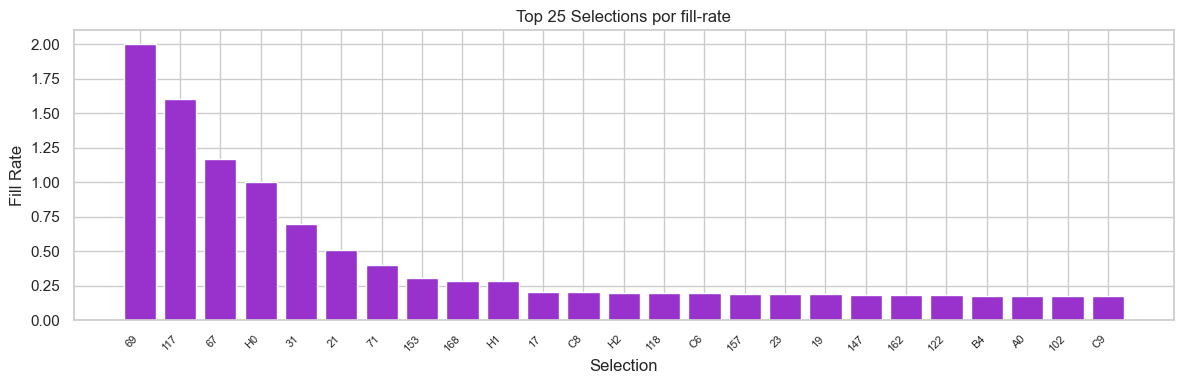

In [16]:
# Análisis por Selection (columna de la máquina)
plano_sel = (
    plano.groupby('Selection')
    .agg(
        avg_par        = ('Par',          'mean'),
        total_qty_sale = ('Quantity Sale', 'sum'),
        n_registros    = ('SALES_DETAIL ID','count'),
    )
    .assign(fill_rate = lambda x: x['total_qty_sale'] / (x['avg_par'] * x['n_registros']))
    .sort_values('fill_rate', ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 4))
top_sel = plano_sel.dropna(subset=['fill_rate']).head(25)
ax.bar(top_sel['Selection'].astype(str), top_sel['fill_rate'], color='darkorchid', edgecolor='white')
ax.set_title('Top 25 Selections por fill-rate')
ax.set_xlabel('Selection')
ax.set_ylabel('Fill Rate')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

---
## Eje 4 — Rentabilidad por producto
Calcula margen unitario (`Unit Price - Unit Cost`) por `Category Tax Name` y `Product Name`
para identificar qué productos son rentables vs cuáles solo generan volumen.

In [17]:
# Calcular margen unitario y total
margin_df = df[df['Unit Price'].notna() & df['Unit Cost'].notna()].copy()
margin_df['unit_margin']  = margin_df['Unit Price'] - margin_df['Unit Cost']
margin_df['margin_pct']   = margin_df['unit_margin'] / margin_df['Unit Price'] * 100
margin_df['total_margin'] = margin_df['unit_margin'] * margin_df['Quantity Sale'].fillna(1)

# Por categoría
cat_margin = (
    margin_df.groupby('Category Tax Name')
    .agg(
        avg_unit_margin  = ('unit_margin',  'mean'),
        avg_margin_pct   = ('margin_pct',   'mean'),
        total_margin     = ('total_margin', 'sum'),
        total_sale       = ('Total Sale',   'sum'),
        n_transac        = ('SALES_DETAIL ID','count'),
    )
    .sort_values('total_margin', ascending=False)
    .reset_index()
)

print('--- Rentabilidad por categoría ---')
display(cat_margin)

--- Rentabilidad por categoría ---


,Category Tax Name,avg_unit_margin,avg_margin_pct,total_margin,total_sale,n_transac
0,Chips,1.220678,-inf,119227.345400,187433.84,63725
1,Pastry,1.471438,-inf,96360.648824,145294.10,43465
2,Candy,1.102640,-inf,85770.767480,170391.82,55346
3,Bottled Drinks,1.189765,46.012258,74347.065000,156934.55,32331
4,Snacks,1.394342,-inf,54771.662100,74835.73,29319
5,Chips - All,1.274739,-inf,29326.890000,45340.00,15155
6,Canned Drinks,0.849356,59.045273,26573.655000,44483.93,14548
7,Water,1.785627,72.502550,13282.600000,18189.40,4052
8,Energy Drinks,1.918406,50.548376,8834.550000,17401.40,2941
9,Sports Drinks,1.671331,65.786476,7206.024167,10897.15,2544


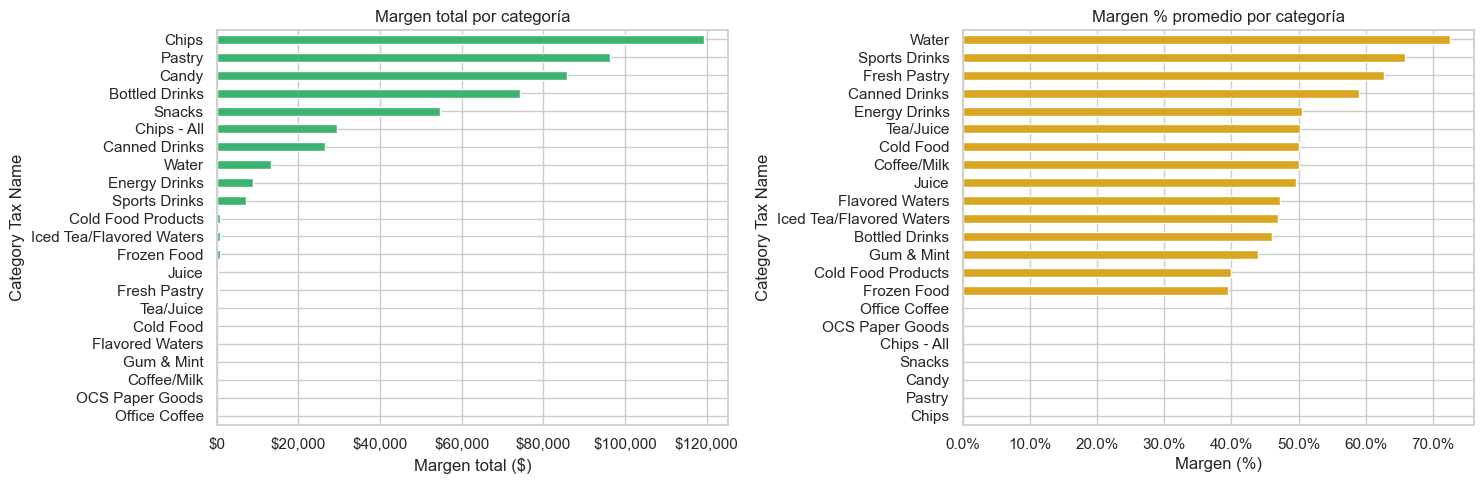

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Margen total por categoría
cat_margin.set_index('Category Tax Name')['total_margin'].sort_values().plot(
    kind='barh', ax=axes[0], color='mediumseagreen', edgecolor='white')
axes[0].set_title('Margen total por categoría')
axes[0].set_xlabel('Margen total ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# % de margen promedio por categoría
cat_margin.set_index('Category Tax Name')['avg_margin_pct'].sort_values().plot(
    kind='barh', ax=axes[1], color='goldenrod', edgecolor='white')
axes[1].set_title('Margen % promedio por categoría')
axes[1].set_xlabel('Margen (%)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()
plt.show()

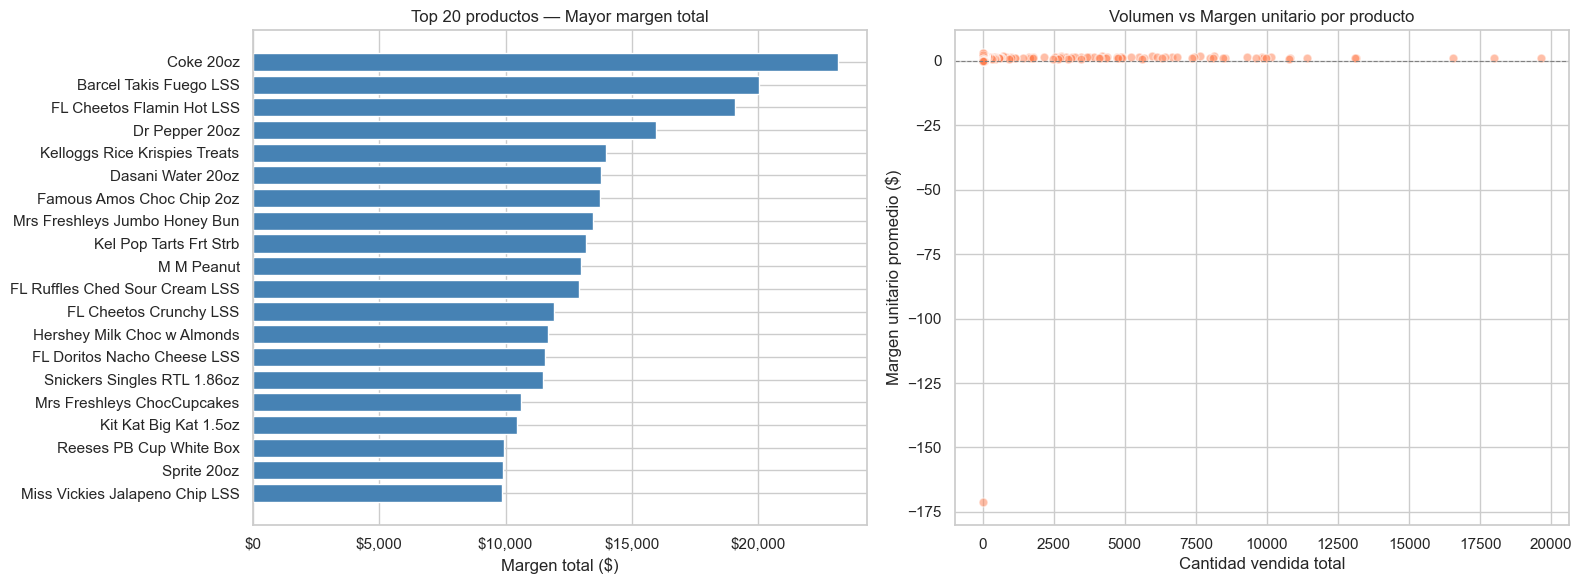

In [19]:
# Top 20 productos por margen total
prod_margin = (
    margin_df.groupby('Product Name')
    .agg(
        avg_unit_margin = ('unit_margin',  'mean'),
        avg_margin_pct  = ('margin_pct',   'mean'),
        total_margin    = ('total_margin', 'sum'),
        total_sale      = ('Total Sale',   'sum'),
        total_qty       = ('Quantity Sale','sum'),
    )
    .sort_values('total_margin', ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top20_m = prod_margin.head(20)
axes[0].barh(top20_m['Product Name'], top20_m['total_margin'], color='steelblue')
axes[0].set_title('Top 20 productos — Mayor margen total')
axes[0].set_xlabel('Margen total ($)')
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Scatter: volumen vs margen unitario
axes[1].scatter(prod_margin['total_qty'], prod_margin['avg_unit_margin'],
                alpha=0.5, color='coral', edgecolors='white', s=40)
axes[1].set_title('Volumen vs Margen unitario por producto')
axes[1].set_xlabel('Cantidad vendida total')
axes[1].set_ylabel('Margen unitario promedio ($)')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

---
## Eje 5 — Segmentación de puntos de venta
Agrupa máquinas usando variables clave: venta promedio, mix de categorías, frecuencia de
transacciones y ubicación. Prepara el terreno para el clustering con K-Means.

In [20]:
# Construir feature table por máquina
base = df.copy()

# Ventas y transacciones
vm_features = (
    base.groupby('vm_control')
    .agg(
        total_sale        = ('Total Sale',      'sum'),
        avg_sale          = ('Total Sale',      'mean'),
        n_transac         = ('SALES_DETAIL ID', 'count'),
        n_products        = ('Product Name',    'nunique'),
        n_categories      = ('Category Tax Name','nunique'),
        avg_qty           = ('Quantity Sale',   'mean'),
        customer          = ('Customer',        'first'),
        op_center         = ('Operation Center','first'),
        pos_location      = ('POS Location',    'first'),
    )
    .reset_index()
)

# Frecuencia de días activos
active_days = (
    base.groupby('vm_control')['Sale Register Date']
    .apply(lambda s: s.dt.date.nunique())
    .rename('active_days')
)
vm_features = vm_features.merge(active_days, on='vm_control')
vm_features['transac_per_day'] = vm_features['n_transac'] / vm_features['active_days'].replace(0, np.nan)

print(f'Feature table: {vm_features.shape}')
display(vm_features.describe())

Feature table: (405, 12)


,vm_control,total_sale,avg_sale,n_transac,n_products,n_categories,avg_qty,active_days,transac_per_day
count,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000
mean,29007.412346,2230.314099,4.579739,671.083951,22.925926,4.266667,1.501812,147.671605,4.169028
std,36075.139762,3061.434936,16.798951,658.316833,12.071546,1.529576,1.166643,68.997943,2.887029
min,6739.000000,2.500000,1.556494,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,23113.000000,691.000000,2.357143,252.000000,8.000000,3.000000,1.167568,101.000000,2.174157
50%,25590.000000,1500.750000,2.824862,506.000000,29.000000,5.000000,1.292605,150.000000,3.304124
75%,35693.000000,2887.500000,3.519385,920.000000,32.000000,5.000000,1.510471,202.000000,5.308057
max,740060.000000,45011.750000,285.000000,7861.000000,41.000000,9.000000,22.000000,289.000000,27.200692


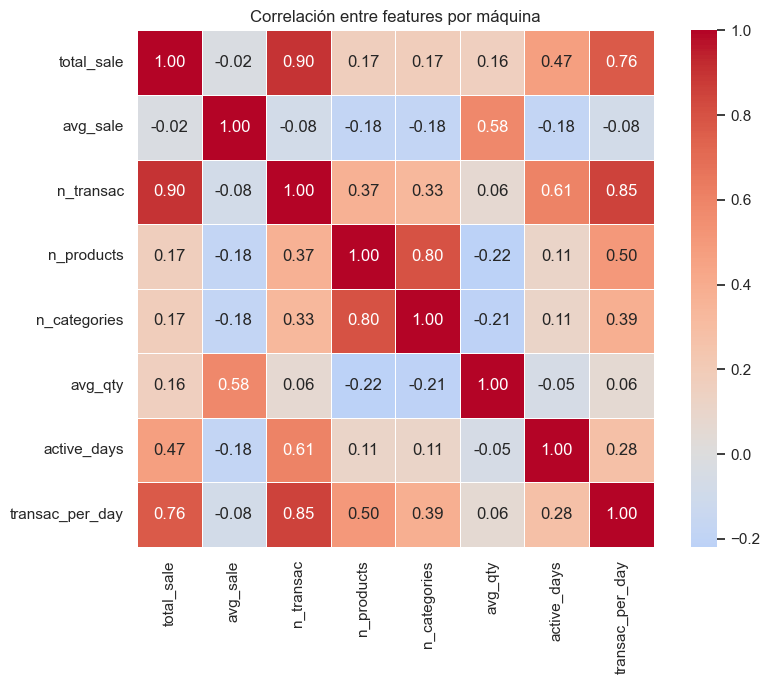

In [21]:
# Matriz de correlación de features numéricas
num_cols = ['total_sale','avg_sale','n_transac','n_products','n_categories',
            'avg_qty','active_days','transac_per_day']

corr = vm_features[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, ax=ax, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            linewidths=0.5, square=True)
ax.set_title('Correlación entre features por máquina')
plt.tight_layout()
plt.show()

Exception in thread Thread-7 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\User\anaconda3\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "c:\Users\User\anaconda3\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\User\anaconda3\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa0 in position 16: invalid start byte
c:\Users\User\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\User\anaconda3\Lib\site-packages\joblib\externals\loky

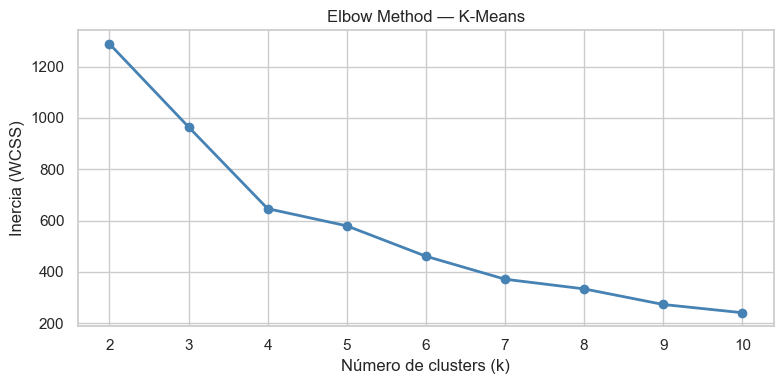

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Preparar features para clustering
feat_cols = ['avg_sale','n_transac','n_products','n_categories','transac_per_day']
X = vm_features[feat_cols].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
inertias = []
K_range  = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), inertias, 'o-', color='steelblue', linewidth=2)
ax.set_title('Elbow Method — K-Means')
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Inercia (WCSS)')
plt.tight_layout()
plt.show()

In [23]:
# Ajusta K según el codo observado (default: 4)
K_OPTIMO = 4

km_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init='auto')
labels   = km_final.fit_predict(X_scaled)

vm_cluster = vm_features.loc[X.index].copy()
vm_cluster['cluster'] = labels

print('Distribución de máquinas por cluster:')
print(vm_cluster['cluster'].value_counts().sort_index())

# Perfil promedio por cluster
print('\n--- Perfil promedio por cluster ---')
display(vm_cluster.groupby('cluster')[feat_cols].mean().round(2))

Distribución de máquinas por cluster:
cluster
0    182
1    143
2     78
3      2
Name: count, dtype: int64

--- Perfil promedio por cluster ---


c:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,avg_sale,n_transac,n_products,n_categories,transac_per_day
cluster,,,,,
0,2.61,490.73,30.26,5.12,3.45
1,4.88,428.13,7.97,2.60,2.65
2,3.18,1554.47,33.77,5.41,8.70
3,217.08,2.00,2.00,1.50,1.25


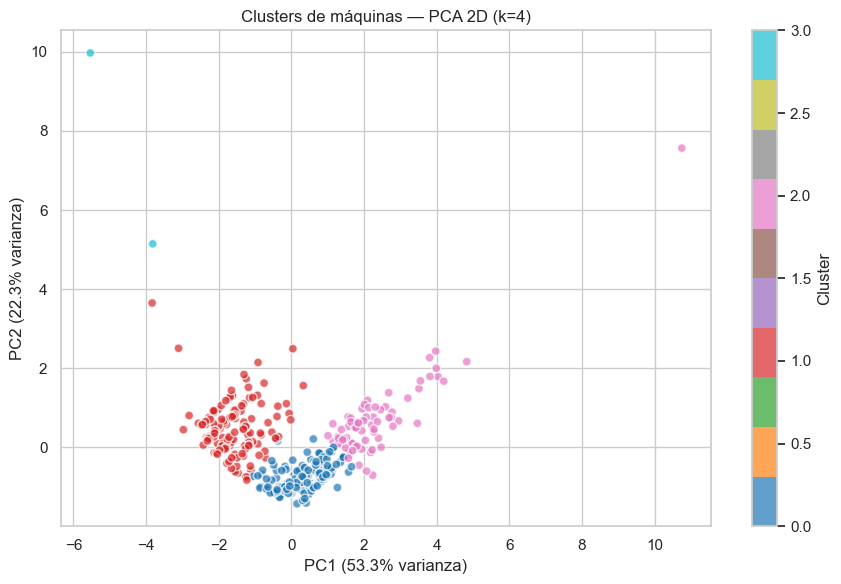

Varianza explicada por 2 PCs: 75.6%


In [24]:
# Visualización PCA 2D de los clusters
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=labels, cmap='tab10', alpha=0.7, s=40, edgecolors='white')
ax.set_title(f'Clusters de máquinas — PCA 2D (k={K_OPTIMO})')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()

print(f'Varianza explicada por 2 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%')

In [25]:
# Exportar feature table con clusters para uso posterior
import os
out_path = '../data/vm_clusters.csv'
vm_cluster.to_csv(out_path, index=False)
print(f'Exportado: {out_path} ({len(vm_cluster):,} máquinas)')

Exportado: ../data/vm_clusters.csv (405 máquinas)
